# Homework 2 — Response Clarity Classification
**Course:** Artificial Intelligence II — Deep Learning for NLP  
**Dataset:** SemEval 2026 Task 6 (QEvasion)  
**Model:** `microsoft/deberta-v3-base`  
**Metric:** Weighted F1-Score  

---
### Input Construction
Question and answer are passed as two sequences to the tokenizer:
```
DeBERTa-v3: [CLS] <question> [SEP] <answer> [SEP]  (no token_type_ids)
```
DeBERTa-v3 uses disentangled attention and an enhanced mask decoder — stronger than BERT but slower to train.


In [1]:
# Ensure sentencepiece is available — required by DeBERTa-v3 tokenizer
import sys, subprocess
try:
    import sentencepiece  # noqa
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'sentencepiece'])

# Clear HuggingFace cache to avoid stale/corrupt model files on Kaggle
import os
os.system('rm -rf ~/.cache/huggingface/hub')


0

In [2]:
import os, gc, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    DebertaV2Config,
    DebertaV2ForSequenceClassification,
    get_cosine_schedule_with_warmup,
)
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from tqdm.auto import tqdm
import copy

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '120'

# Reproducibility
SEED = 42
def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


## 1. Load Data

In [3]:
for attempt in range(5):
    try:
        ds = load_dataset('ailsntua/QEvasion')
        print('Loaded successfully'); break
    except Exception as e:
        print(f'Attempt {attempt+1}/5 failed: {e}')
        if attempt < 4: time.sleep(10)
        else: raise

train_df = ds['train'].to_pandas()
test_df  = ds['test'].to_pandas()
print(f'Train: {train_df.shape} | Test: {test_df.shape}')
print('\nLabel distribution (train):')
print(train_df['clarity_label'].value_counts())
train_df[['question', 'interview_answer', 'clarity_label']].head(3)


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

Loaded successfully
Train: (3448, 20) | Test: (308, 20)

Label distribution (train):
clarity_label
Ambivalent         2040
Clear Reply        1052
Clear Non-Reply     356
Name: count, dtype: int64


,question,interview_answer,clarity_label
0,How would you respond to the accusation that t...,"Well, look, first of all, theI am sincere abou...",Clear Reply
1,Do you think President Xi is being sincere abo...,"Well, look, first of all, theI am sincere abou...",Ambivalent
2,Do you believe the country's slowdown and gro...,"Look, I think China has a difficult economic p...",Ambivalent


In [4]:
Q_COL, A_COL, L_COL = 'question', 'interview_answer', 'clarity_label'
ID_COL = None

LABEL_NAMES = ['Clear Reply', 'Ambivalent', 'Clear Non-Reply']
id2label = {i: l for i, l in enumerate(LABEL_NAMES)}
label2id = {l: i for i, l in enumerate(LABEL_NAMES)}

# Handles label variants e.g. 'Ambivalent Reply' → 1
_norm = {'Clear Reply': 0, 'Ambivalent': 1, 'Ambivalent Reply': 1, 'Clear Non-Reply': 2}
def normalize_label(x):
    try: return int(x)
    except (TypeError, ValueError): pass
    s = str(x).strip()
    if s in _norm: return _norm[s]
    s_l = s.lower().replace('-', ' ').replace('_', ' ').strip()
    for k, v in _norm.items():
        if s_l == k.lower(): return v
    raise ValueError(f'unknown label: {x!r}')

train_df = train_df.dropna(subset=[L_COL, Q_COL, A_COL]).reset_index(drop=True)
train_df['label_id'] = train_df[L_COL].map(normalize_label)
test_df = test_df.reset_index(drop=True)
print(train_df['label_id'].value_counts().rename(index=id2label))


label_id
Ambivalent         2040
Clear Reply        1052
Clear Non-Reply     356
Name: count, dtype: int64


## 2. Exploratory Data Analysis

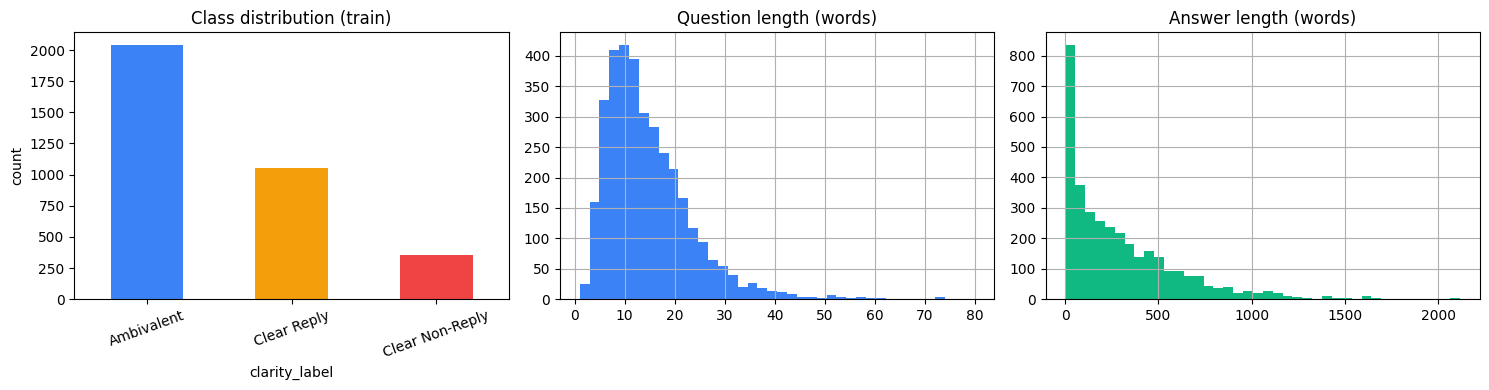

Q words -> mean 14.5  p95 31  max 80
A words -> mean 293.6  p95 888  max 2117


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
train_df[L_COL].value_counts().plot(
    kind='bar', ax=axes[0], color=['#3b82f6', '#f59e0b', '#ef4444']
)
axes[0].set_title('Class distribution (train)'); axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=20)
train_df[Q_COL].astype(str).str.split().str.len().hist(bins=40, ax=axes[1], color='#3b82f6')
axes[1].set_title('Question length (words)')
train_df[A_COL].astype(str).str.split().str.len().hist(bins=40, ax=axes[2], color='#10b981')
axes[2].set_title('Answer length (words)')
plt.tight_layout(); plt.show()

ql = train_df[Q_COL].astype(str).str.split().str.len()
al = train_df[A_COL].astype(str).str.split().str.len()
print(f'Q words -> mean {ql.mean():.1f}  p95 {ql.quantile(.95):.0f}  max {ql.max()}')
print(f'A words -> mean {al.mean():.1f}  p95 {al.quantile(.95):.0f}  max {al.max()}')


## 3. Label Encoding & Train / Validation Split

Minority classes are oversampled to match the majority class size **before** the split.


In [6]:
# Separate by class
df_0 = train_df[train_df['label_id'] == 0]  # Clear Reply
df_1 = train_df[train_df['label_id'] == 1]  # Ambivalent
df_2 = train_df[train_df['label_id'] == 2]  # Clear Non-Reply

# Upsample minority classes to the size of the majority class
df_1_upsampled = resample(df_1, replace=True, n_samples=len(df_0), random_state=SEED)
df_2_upsampled = resample(df_2, replace=True, n_samples=len(df_0), random_state=SEED)

train_df = pd.concat([df_0, df_1_upsampled, df_2_upsampled])
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print('Class distribution after oversampling:')
print(train_df['label_id'].value_counts().rename(index=id2label))


Class distribution after oversampling:
label_id
Clear Non-Reply    1052
Clear Reply        1052
Ambivalent         1052
Name: count, dtype: int64


## 4. Tokenization & Dataset


In [7]:
MODEL_NAME = 'microsoft/deberta-v3-base'
MAX_LEN    = 384   # covers >95% of Q+A pairs
BATCH      = 8     # smaller batch — DeBERTa-v3 is ~184M params
EPOCHS     = 6
LR         = 2e-5  # lower LR than BERT for stability
WD         = 0.01
WARMUP     = 0.1
DROPOUT    = 0.1
VAL_FRAC   = 0.10
ACCUM      = 4    # effective batch = 32 via gradient accumulation


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

class QADataset(Dataset):
    """Tokenises (question, answer) pairs for sequence classification."""
    def __init__(self, questions, answers, labels=None, tok=None, max_len=MAX_LEN):
        self.q = [str(x) for x in questions]
        self.a = [str(x) for x in answers]
        self.y = labels; self.tok = tok; self.max_len = max_len
    def __len__(self): return len(self.q)
    def __getitem__(self, i):
        enc = self.tok(self.q[i], self.a[i], truncation=True, max_length=self.max_len,
                       padding='max_length', return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.y is not None:
            item['labels'] = torch.tensor(int(self.y[i]), dtype=torch.long)
        return item

# Stratified split — val keeps natural class distribution
tr_idx, val_idx = train_test_split(
    np.arange(len(train_df)), test_size=VAL_FRAC,
    random_state=SEED, stratify=train_df['label_id']
)

tr_ds  = QADataset(train_df.iloc[tr_idx][Q_COL].values,  train_df.iloc[tr_idx][A_COL].values,
                   train_df.iloc[tr_idx]['label_id'].values, tokenizer)
val_ds = QADataset(train_df.iloc[val_idx][Q_COL].values, train_df.iloc[val_idx][A_COL].values,
                   train_df.iloc[val_idx]['label_id'].values, tokenizer)
te_ds  = QADataset(test_df[Q_COL].values, test_df[A_COL].values, None, tokenizer)

tr_dl  = DataLoader(tr_ds,  batch_size=BATCH,   shuffle=True,  num_workers=2, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=BATCH*2, shuffle=False, num_workers=2, pin_memory=True)
te_dl  = DataLoader(te_ds,  batch_size=BATCH*2, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train {len(tr_ds)} | Val {len(val_ds)} | Test {len(te_ds)}')


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Train 2840 | Val 316 | Test 308


## 5. Model


In [8]:
# Download pretrained backbone weights from HuggingFace CDN
!wget -q https://huggingface.co/microsoft/deberta-v3-base/resolve/main/pytorch_model.bin


In [9]:
# Re-seed before model init for reproducibility
seed_all(SEED)

# Build model from config + load pretrained backbone (strict=False ignores LM head keys)
config = DebertaV2Config.from_pretrained('microsoft/deberta-v3-base', num_labels=3)
config.id2label = id2label
config.label2id = label2id

model = DebertaV2ForSequenceClassification(config)
state_dict = torch.load('pytorch_model.bin', map_location=DEVICE)
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print(f'Missing keys (classifier — init randomly): {len(missing)}')
print(f'Unexpected keys (ignored):                 {len(unexpected)}')
model.to(DEVICE)

# Focal loss downweights easy examples, helping with class imbalance
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

alpha = torch.tensor([1.0, 1.5, 1.5], dtype=torch.float).to(DEVICE)
criterion = FocalLoss(alpha=alpha, gamma=2.0)

# Optimizer & cosine scheduler with warmup
optimizer   = AdamW(model.parameters(), lr=2e-5, eps=1e-6)
total_steps = (len(tr_dl) * EPOCHS) // ACCUM
scheduler   = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


Missing keys (classifier — init randomly): 4
Unexpected keys (ignored):                 12


In [10]:
def evaluate(model, dataloader):
    """Returns loss, accuracy, F1-weighted, F1-macro, y_pred, y_true."""
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0
    with torch.no_grad():
        for batch in dataloader:
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**{k: v for k, v in batch.items() if k != 'labels'})
            loss    = criterion(outputs.logits, batch['labels'])
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].cpu().numpy())
    avg_loss   = total_loss / len(dataloader)
    acc        = accuracy_score(all_labels, all_preds)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    f1_macro    = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1_weighted, f1_macro, all_preds, all_labels


## 6. Training Loop


In [11]:
history = {'tr_loss': [], 'val_loss': [], 'val_f1m': [], 'val_f1w': []}
best_f1, best_weights = 0.0, None

print(f'Starting Training on {DEVICE}...')

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    pbar = tqdm(enumerate(tr_dl), total=len(tr_dl), desc=f'Epoch {epoch}')

    for step, batch in pbar:
        batch   = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**{k: v for k, v in batch.items() if k != 'labels'})
        loss    = criterion(outputs.logits, batch['labels']) / ACCUM
        loss.backward()

        if (step + 1) % ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()

        train_loss += loss.item() * ACCUM
        pbar.set_postfix({'loss': f'{loss.item()*ACCUM:.4f}'})

    val_loss, val_acc, val_f1w, val_f1m, _, _ = evaluate(model, val_dl)
    history['tr_loss'].append(train_loss / len(tr_dl))
    history['val_loss'].append(val_loss)
    history['val_f1m'].append(val_f1m)
    history['val_f1w'].append(val_f1w)

    print(f'\n--- Epoch {epoch} Results ---')
    print(f'Train Loss: {history["tr_loss"][-1]:.4f} | Val Loss: {val_loss:.4f}')
    print(f'F1-Weighted: {val_f1w:.4f} | F1-Macro: {val_f1m:.4f}')

    if val_f1w > best_f1:
        best_f1 = val_f1w
        best_weights = copy.deepcopy(model.state_dict())
        print('   ↑ New Best Score!')
  

Starting Training on cuda...


Epoch 1:   0%|          | 0/355 [00:00<?, ?it/s]


--- Epoch 1 Results ---
Train Loss: 0.7985 | Val Loss: 0.7190
F1-Weighted: 0.3865 | F1-Macro: 0.3858
   ↑ New Best Score!


Epoch 2:   0%|          | 0/355 [00:00<?, ?it/s]


--- Epoch 2 Results ---
Train Loss: 0.6288 | Val Loss: 0.5407
F1-Weighted: 0.4589 | F1-Macro: 0.4579
   ↑ New Best Score!


...


--- Epoch 4 Results ---
Train Loss: 0.3601 | Val Loss: 0.3354
F1-Weighted: 0.5301 | F1-Macro: 0.5288
   ↑ New Best Score!


Epoch 5:   0%|          | 0/355 [00:00<?, ?it/s]


--- Epoch 5 Results ---
Train Loss: 0.3008 | Val Loss: 0.3503
F1-Weighted: 0.5555 | F1-Macro: 0.5544
   ↑ New Best Score!


Epoch 6:   0%|          | 0/355 [00:00<?, ?it/s]


--- Epoch 6 Results ---
Train Loss: 0.2626 | Val Loss: 0.3245
F1-Weighted: 0.5904 | F1-Macro: 0.5893
   ↑ New Best Score!


## 7. Training Curves


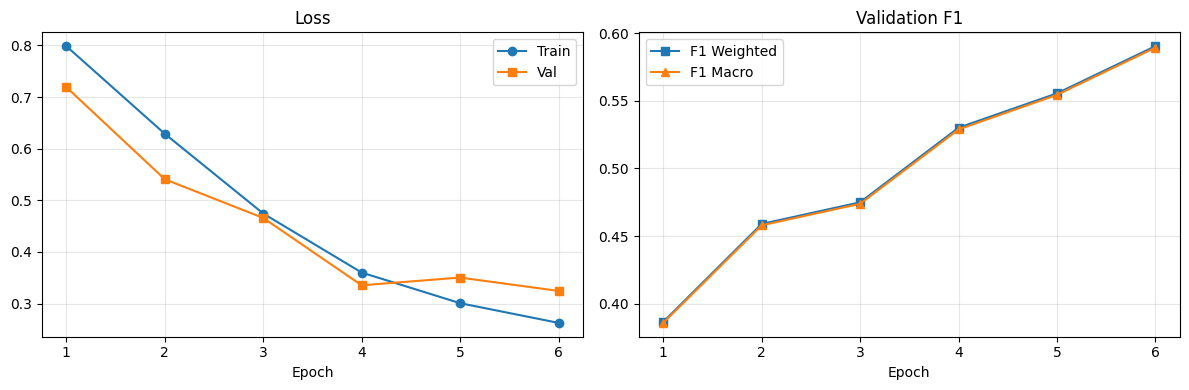

In [12]:
x = np.arange(1, len(history['tr_loss']) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(x, history['tr_loss'], 'o-', label='Train'); ax[0].plot(x, history['val_loss'], 's-', label='Val')
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(x, history['val_f1w'], 's-', label='F1 Weighted')
ax[1].plot(x, history['val_f1m'], '^-', label='F1 Macro')
ax[1].set_title('Validation F1'); ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


## 8. Final Report — Validation Set


VAL  acc=0.6551  P=0.8691  R=0.6551  F1-Weighted=0.7197  F1-Macro=0.5893

                  precision    recall  f1-score   support

    Clear Reply     0.1143    0.6667    0.1951        18
     Ambivalent     0.8857    0.5027    0.6414       185
Clear Non-Reply     0.9623    0.9027    0.9315       113

       accuracy                         0.6551       316
      macro avg     0.6541    0.6907    0.5893       316
   weighted avg     0.8691    0.6551    0.7197       316



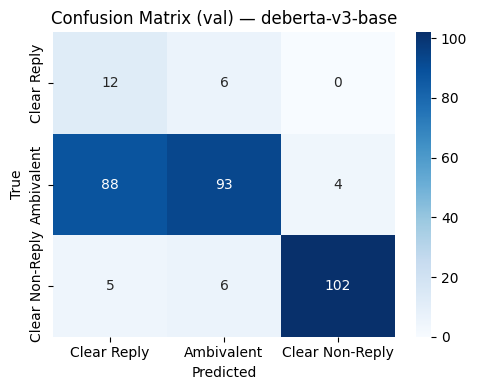

In [13]:
vl, va, vf1w, vf1m, y_true, y_pred = evaluate(model, val_dl)
p_, r_, f_, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
print(f'VAL  acc={va:.4f}  P={p_:.4f}  R={r_:.4f}  F1-Weighted={f_:.4f}  F1-Macro={vf1m:.4f}')
print('\n', classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix (val) — deberta-v3-base')
plt.tight_layout(); plt.show()


## 9. Error Analysis


Accuracy by true class:
true
Ambivalent         0.5027
Clear Non-Reply    0.9027
Clear Reply        0.6667
Name: ok, dtype: float64

Accuracy by q_len quartile:
q_len
(0.999, 7.0]    0.6786
(7.0, 11.0]     0.6053
(11.0, 16.0]    0.6962
(16.0, 62.0]    0.6364
Name: ok, dtype: float64

Accuracy by a_len quartile:
a_len
(0.999, 49.0]      0.7875
(49.0, 190.0]      0.6154
(190.0, 398.5]     0.5696
(398.5, 2117.0]    0.6456
Name: ok, dtype: float64


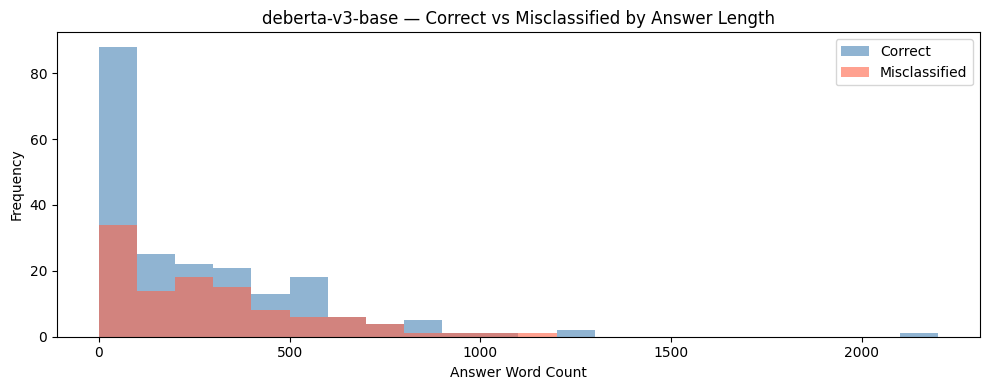


--- Sample misclassifications ---
true=Ambivalent       pred=Clear Reply      | Q: What will you do if it's not working?... | A: What you do is, you get your diplomats working with Russian diplomats, as well as EU diplomats, to see if there is not common ground. In other words, there has ...
true=Ambivalent       pred=Clear Reply      | Q: Is that enough—that kind of a letter?... | A: No, I think the Fed has a very important role and especially psychological. I mean, if you look at the—the Fed has a massive impact. Lots of it is psychological...
true=Clear Non-Reply  pred=Clear Reply      | Q: The dilemma of being a Nobel Peace Prize winner and preparing to attack Syria.... | A: I would refer you to the speech that I gave when I received the Nobel Prize. And I think I started the speech by saying that, compared to previous recipients, I...
true=Ambivalent       pred=Clear Reply      | Q:  What is your guidance to Republicans who may be threatening to filibuster a Supreme Court nominee

In [14]:
val_view = train_df.iloc[val_idx].reset_index(drop=True).copy()
val_view['true'] = [id2label[int(i)] for i in y_true]
val_view['pred'] = [id2label[int(i)] for i in y_pred]
val_view['ok']   = (np.array(y_true) == np.array(y_pred))  # element-wise comparison
val_view['q_len'] = val_view[Q_COL].astype(str).str.split().str.len()
val_view['a_len'] = val_view[A_COL].astype(str).str.split().str.len()

print('Accuracy by true class:')
print(val_view.groupby('true')['ok'].mean().round(4))
for col in ['q_len', 'a_len']:
    bins = pd.qcut(val_view[col], 4, duplicates='drop')
    print(f'\nAccuracy by {col} quartile:')
    print(val_view.groupby(bins)['ok'].mean().round(4))

# ── Plot: Correct vs Misclassified by answer length ──
fig, ax = plt.subplots(figsize=(10, 4))
correct = val_view[val_view['ok']]['a_len']
wrong_  = val_view[~val_view['ok']]['a_len']
bins = range(0, int(val_view['a_len'].max()) + 100, 100)
ax.hist(correct, bins=bins, alpha=0.6, color='steelblue', label='Correct')
ax.hist(wrong_,  bins=bins, alpha=0.6, color='tomato',    label='Misclassified')
ax.set_xlabel('Answer Word Count')
ax.set_ylabel('Frequency')
ax.set_title('deberta-v3-base — Correct vs Misclassified by Answer Length')
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/error_analysis_deberta.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Sample misclassifications ---')
wrong = val_view[~val_view['ok']].head(8)
for _, r in wrong.iterrows():
    print(f"true={r['true']:<16} pred={r['pred']:<16} | Q: {str(r[Q_COL])[:120]}... | A: {str(r[A_COL])[:160]}...")

## 10. Submission


In [15]:
seed_all(SEED)
model.load_state_dict(best_weights)
USE_AMP = torch.cuda.is_available()

@torch.no_grad()
def predict(model, dl):
    model.eval(); out = []
    for batch in dl:
        batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(**batch).logits
        out.append(logits.argmax(-1).cpu().numpy())
    return np.concatenate(out)

test_preds = predict(model, te_dl)
test_ids   = test_df[ID_COL].values if ID_COL else np.arange(len(test_df))
sub = pd.DataFrame({'Id': test_ids, 'Predicted': [id2label[int(i)] for i in test_preds]})
sub.to_csv('/kaggle/working/submission microsoft-deberta-v3-base.csv', index=False)
sub.to_csv('/kaggle/working/submission.csv', index=False)
print('submission.csv saved — rows:', len(sub))
print(sub['Predicted'].value_counts())
sub.head()


submission.csv saved — rows: 308
Predicted
Ambivalent         265
Clear Non-Reply     32
Clear Reply         11
Name: count, dtype: int64


,Id,Predicted
0,0,Ambivalent
1,1,Ambivalent
2,2,Ambivalent
3,3,Clear Non-Reply
4,4,Ambivalent
